In [1]:
pip install torch numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 32.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 32.7 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.2
    Uninstalling sympy-1.13.2:
      Successfully uninstalled sympy-1.13.2
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np

In [6]:
def generate_housing_data(n_samples=500):
    sqft     = np.random.uniform(500, 4000, n_samples)
    bedrooms = np.random.randint(1, 6, n_samples)
    distance = np.random.uniform(1, 30, n_samples)

    noise = np.random.normal(0, 15_000, n_samples)
    price = 150*sqft + 10_000*bedrooms - 5_000*distance + 50_000 + noise

    X = np.column_stack([sqft, bedrooms, distance])
    y = price.reshape(-1, 1)

    return X, y

In [7]:
X, y = generate_housing_data()
print(X.shape)
print(y.shape)

(500, 3)
(500, 1)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [11]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(350, 3)
(75, 3)
(75, 3)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [13]:
import torch

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
y_val   = torch.tensor(y_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

In [15]:
import torch.nn as nn

In [16]:
class LinearRegressionModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

In [17]:
model = LinearRegressionModel(n_features=3)
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)


In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [25]:
train_losses = []
epochs = 500

for epoch in range(epochs):
    model.train()
    
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.0f}")

Epoch 0 | Loss: 212985616
Epoch 50 | Loss: 212985232
Epoch 100 | Loss: 212985120
Epoch 150 | Loss: 212985168
Epoch 200 | Loss: 212985120
Epoch 250 | Loss: 212985184
Epoch 300 | Loss: 212985136
Epoch 350 | Loss: 212985168
Epoch 400 | Loss: 212985168
Epoch 450 | Loss: 212985168


In [26]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

In [27]:
# RMSE — root mean squared error
rmse = torch.sqrt(torch.mean((y_pred_test - y_test) ** 2)).item()

# R² — how much variance the model explains
ss_res = torch.sum((y_test - y_pred_test) ** 2)
ss_tot = torch.sum((y_test - y_test.mean()) ** 2)
r2 = (1 - ss_res / ss_tot).item()

In [28]:
print(f"Test RMSE: ${rmse:.0f}")
print(f"Test R²: {r2:.4f}")

Test RMSE: $13873
Test R²: 0.9912


In [24]:
import matplotlib.pyplot as plt

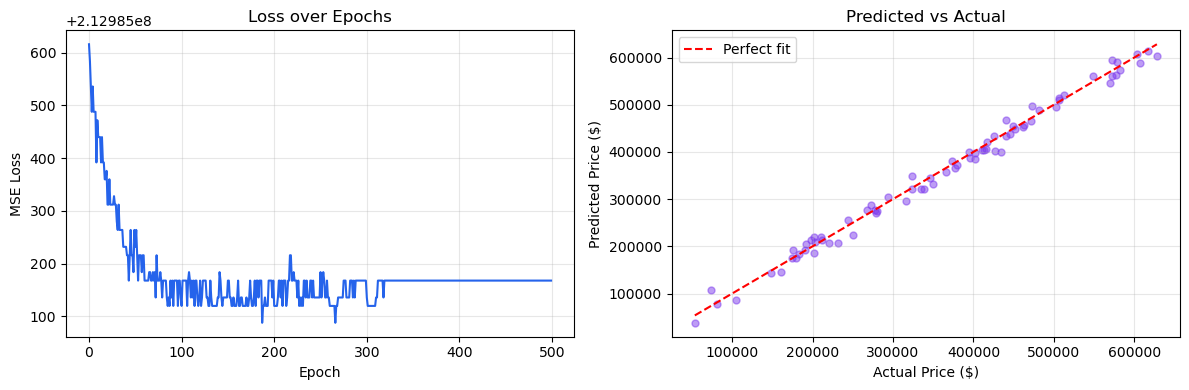

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss curve
axes[0].plot(train_losses, color="#2563EB")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

# Plot 2: Predicted vs Actual
axes[1].scatter(y_test.numpy(), y_pred_test.numpy(), alpha=0.5, color="#7C3AED", s=25)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect fit")
axes[1].set_title("Predicted vs Actual")
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
torch.save(model.state_dict(), "model.pth")

In [31]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)